In [ ]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
# import sys
# sys.path.insert(0, '/home/kat/Repos/SALSA/')

### Load dataset.

In [2]:
import pandas as pd
from rdkit import Chem

df = pd.read_csv("human_carbonic_anhydrase_ii.csv", sep=";")
df = df[["Smiles", "Standard Type", "Standard Relation", 
         "Standard Value", "Standard Units"]]
df.dropna(inplace=True)
df["Mol"] = df["Smiles"].apply(Chem.MolFromSmiles)
display(df[:10])

,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Mol
6,Nc1cc(Cl)c(S(N)(=O)=O)cc1S(N)(=O)=O,Ki,'=',75.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f88e710>
7,NS(=O)(=O)c1ccc(CNC(=O)Cc2ccccc2Br)cc1,Ki,'=',0.77,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885e40>
8,NS(=O)(=O)c1ccc(NC(=O)Cc2ccc(F)cc2)c(Cl)c1,Ki,'=',9.50,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885e90>
9,CS(=O)(=O)Oc1ccc2c(c1)OS(=O)(=O)C=C2,Ki,'=',2.10,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885f80>
11,O=S(=O)(NCCc1ccccc1)NCCc1ccccc1,Ki,'>',200000.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885df0>
12,Nc1ccc(S(=O)(=O)Nc2ccc(S(N)(=O)=O)cc2)cc1,Ki,'=',33.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885da0>
13,Cn1nc(S(N)(=O)=O)sc1=N,Ki,'=',19.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885d50>
14,NS(=O)(=O)c1ccc(N2CCCCS2(=O)=O)cc1,Ki,'=',9.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885cb0>
16,NS(=O)(=O)c1ccc(CNC(=O)Cc2cccs2)cc1,Ki,'=',52.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885710>
17,O=[Te](=O)([O-])[O-].[Na+].[Na+],Ki,'=',920000.00,nM,<rdkit.Chem.rdchem.Mol object at 0x7f2b7f885620>


# <font color=blue> Look at y (target) distributions.

<Figure size 360x720 with 0 Axes>

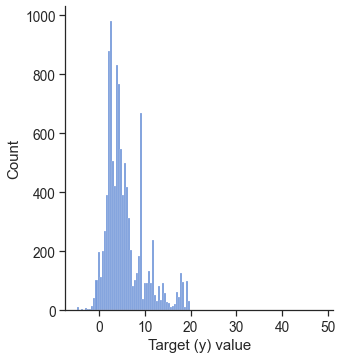

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

plt.figure(figsize=(5,10))

y_reg = df["Standard Value"].to_numpy()
y_log = np.log(y_reg)
sns.displot(y_log)
plt.xlabel('Target (y) value')
plt.show()

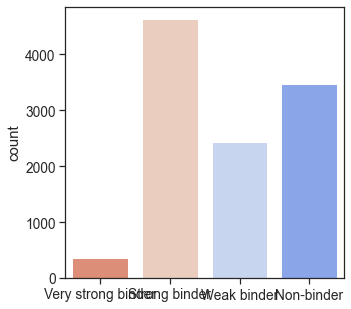

In [31]:
y_reg = df["Standard Value"].to_numpy()
y_log = np.log(y_reg)
cuts = [0,4,6]
y = np.digitize(y_log, cuts)
                     
plt.figure(figsize=(5,5))
sns.countplot(y, palette='coolwarm_r')
labs = ['Non-binder','Weak binder','Strong binder','Very strong binder']
labs = labs[::-1]

plt.xticks(range(len(cuts)+1),labs)
# plt.xlabel('Target (y) label')

display()

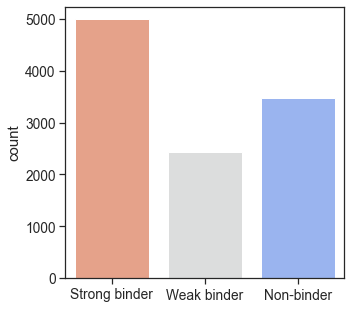

In [35]:
y_reg = df["Standard Value"].to_numpy()
y_log = np.log(y_reg)
cuts = [4, 6]

y_tern = np.digitize(y_log, cuts)
                     
plt.figure(figsize=(5,5))
sns.countplot(y_tern, palette='coolwarm_r')
labs = ['Non-binder','Weak binder','Strong binder','Very strong binder']
labs = labs[::-1][1:]
plt.xticks(range(len(cuts)+1),labs)
# plt.xlabel('Target (y) label')

display()

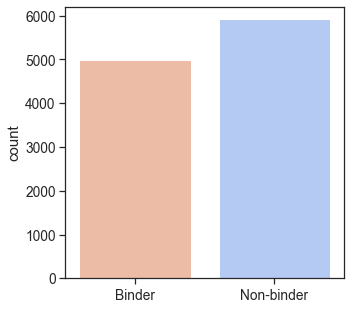

In [36]:
y_reg = df["Standard Value"].to_numpy()
y_log = np.log(y_reg)
cuts = [4]

y_binary = np.digitize(y_log, cuts)

plt.figure(figsize=(5,5))

sns.countplot(y_binary, palette='coolwarm_r')
labs = ['Binder','Non-binder']
plt.xticks(range(len(cuts)+1),labs)
display()

## <font color=blue> Save y csv ... 

In [39]:
df_y = pd.DataFrame()
df_y['raw'] = y_log
df_y['binary'] = y_binary
df_y['ternary'] = y_tern
display(df_y)

,raw,binary,ternary
0,4.317488,1,1
1,-0.261365,0,0
2,2.251292,0,0
3,0.741937,0,0
4,12.206073,1,2
...,...,...,...
10896,2.302585,0,0
10897,2.639057,0,0
10898,3.044522,0,0
10899,19.113828,1,2


In [43]:
df_y.to_csv('CA2_y.csv',index=False)
# Test loading in ... 

test = pd.read_csv('CA2_y.csv')
test

,raw,binary,ternary
0,4.317488,1,1
1,-0.261365,0,0
2,2.251292,0,0
3,0.741937,0,0
4,12.206073,1,2
...,...,...,...
10896,2.302585,0,0
10897,2.639057,0,0
10898,3.044522,0,0
10899,19.113828,1,2


# <font color=blue> Featurize x !!

In [44]:
from utilities.fp_utils import get_fps_in_parallel
import numpy as np

fps = get_fps_in_parallel(df.Smiles,fp_type='morgan',counts=True,bits=1024,radius=4)
fps = np.stack(fps)
display(fps.shape)

(10901, 1024)

### Variance threshold ...

In [61]:
from sklearn.feature_selection import VarianceThreshold

var_thresh = 0.925

thresher = VarianceThreshold(threshold=(var_thresh*(1-var_thresh)))
threshed = thresher.fit_transform(fps)
display(threshed.shape)

(10901, 227)

# <font color=blue> Train !!!

In [58]:
X = threshed
# y = y_binary
y = y_tern

# # # # # # # # # # # # # #
from imblearn.ensemble import BalancedRandomForestClassifier as BalRF
from sklearn.model_selection import StratifiedKFold

seedy = 666

skf = StratifiedKFold(n_splits=5)
skf.get_n_splits(X, y)

clf = BalRF(n_estimators=100, max_features="auto",sampling_strategy='auto',
            random_state=seedy,n_jobs=-1,oob_score=True)

df_y = pd.DataFrame(y_binary, columns=['y_test'])

oobs = []
for i,(train_idx, test_idx) in enumerate(skf.split(X,y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf.fit(X_train,y_train)
    print(f'OOB, split {i}: {clf.oob_score_}')

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    df_y.loc[test_idx,'y_prob'] = y_prob[:,1]
    df_y.loc[test_idx,'y_pred'] = y_pred
    oobs.append(clf.oob_score_)
    
print(f"Mean OOB: {sum(oobs)/5}")

OOB, split 0: 0.8036697247706422
OOB, split 1: 0.8160761380575622
OOB, split 2: 0.8007109276459121
OOB, split 3: 0.8059855521155831
OOB, split 4: 0.8103428505905286
Mean OOB: 0.8073570386360457


## <font color=blue> Save X as csv ... 

In [59]:
df_X = pd.DataFrame(threshed)

df_X.to_csv('CA2_X.csv',index=False)

test = pd.read_csv('CA2_X.csv')
test

,0,1,2,3,4,5,6,7,8,9,...,217,218,219,220,221,222,223,224,225,226
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,2,0,2,0,...,0,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10896,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,1,0,0,1,0
10897,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,1,0
10898,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
10899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# <font color=blue> Construct dataset for Junier ...

In [ ]:
X.shape

In [ ]:
X